# Clusterização de Municípios Brasileiros — Análise Exploratória (EDA)

**Objetivo:** agrupar municípios brasileiros semelhantes com base em características demográficas e econômicas, sem usar rótulos.

**Fonte dos dados:** IBGE (Instituto Brasileiro de Geografia e Estatística), via API oficial de localidades e API SIDRA. O IBGE é o órgão federal responsável pelos dados também catalogados no [Portal Brasileiro de Dados Abertos](https://dados.gov.br). O script de coleta está em `../src/baixar_dados.py`.

Este notebook contém **somente EDA** (análise exploratória). Nenhum modelo de clusterização é treinado aqui — isso é feito nos notebooks seguintes (`02_Baseline`, `03_Comparacao_Modelos`, `04_Avaliacao_Conclusao`).

**Variáveis do dataset (nível município, ano de referência 2021):**
- `codigo_municipio`, `municipio`: identificação
- `uf_sigla`, `uf_nome`, `regiao`, `mesorregiao`, `microrregiao`: localização geográfica (categóricas)
- `populacao`: população estimada
- `pib_total_mil_reais`: Produto Interno Bruto total (mil R$)
- `vab_agropecuaria_mil_reais`, `vab_industria_mil_reais`, `vab_servicos_mil_reais`, `vab_adm_publica_mil_reais`: valor adicionado bruto por setor econômico (mil R$)
- `pib_per_capita_reais`: PIB per capita (R$), calculado a partir do PIB total e da população

## 1. Imports e configuração

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

PASTA_REPORTS = "../reports"
os.makedirs(PASTA_REPORTS, exist_ok=True)

## 2. Carregar os dados

In [2]:
CAMINHO_DADOS = "../data/municipios_brasil.csv"

df = pd.read_csv(CAMINHO_DADOS)
print("Linhas x Colunas:", df.shape)
df.head()

Linhas x Colunas: (5571, 14)


,codigo_municipio,municipio,uf_sigla,uf_nome,regiao,mesorregiao,microrregiao,populacao,pib_total_mil_reais,vab_adm_publica_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,pib_per_capita_reais
0,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,22516.0,734467.0,173122.0,311469.0,27845.0,172435.0,32619.781489
1,1100023,Ariquemes,RO,Rondônia,Norte,Leste Rondoniense,Ariquemes,111148.0,3211294.0,782306.0,293001.0,407675.0,1307977.0,28892.053838
2,1100031,Cabixi,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,5067.0,238414.0,46579.0,136659.0,8117.0,35866.0,47052.299191
3,1100049,Cacoal,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,86416.0,2792506.0,629109.0,341315.0,236801.0,1200654.0,32314.687095
4,1100056,Cerejeiras,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,16088.0,743062.0,123365.0,151690.0,27433.0,308668.0,46187.344605


## 3. Qualidade dos dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   codigo_municipio            5571 non-null   int64  
 1   municipio                   5571 non-null   object 
 2   uf_sigla                    5571 non-null   object 
 3   uf_nome                     5571 non-null   object 
 4   regiao                      5571 non-null   object 
 5   mesorregiao                 5570 non-null   object 
 6   microrregiao                5570 non-null   object 
 7   populacao                   5570 non-null   float64
 8   pib_total_mil_reais         5570 non-null   float64
 9   vab_adm_publica_mil_reais   5570 non-null   float64
 10  vab_agropecuaria_mil_reais  5570 non-null   float64
 11  vab_industria_mil_reais     5570 non-null   float64
 12  vab_servicos_mil_reais      5570 non-null   float64
 13  pib_per_capita_reais        5570 

In [4]:
# Valores nulos por coluna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]

mesorregiao                   1
microrregiao                  1
populacao                     1
pib_total_mil_reais           1
vab_adm_publica_mil_reais     1
vab_agropecuaria_mil_reais    1
vab_industria_mil_reais       1
vab_servicos_mil_reais        1
pib_per_capita_reais          1
dtype: int64

In [5]:
# Município(s) com dado ausente (série do IBGE incompleta para município recém-criado)
df[df["populacao"].isnull()]

,codigo_municipio,municipio,uf_sigla,uf_nome,regiao,mesorregiao,microrregiao,populacao,pib_total_mil_reais,vab_adm_publica_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,pib_per_capita_reais
5199,5101837,Boa Esperança do Norte,MT,Mato Grosso,Centro-Oeste,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Linhas duplicadas
print("Duplicadas:", df.duplicated().sum())
print("Códigos de município duplicados:", df["codigo_municipio"].duplicated().sum())

Duplicadas: 0
Códigos de município duplicados: 0


## 4. Estatísticas descritivas

In [7]:
colunas_numericas = [
    "populacao",
    "pib_total_mil_reais",
    "vab_agropecuaria_mil_reais",
    "vab_industria_mil_reais",
    "vab_servicos_mil_reais",
    "vab_adm_publica_mil_reais",
    "pib_per_capita_reais",
]

df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
populacao,5570.0,3.829760e+04,2.242882e+05,771.000000,5454.000000,11732.000000,25764.750000,1.239637e+07
pib_total_mil_reais,5570.0,1.617979e+06,1.377458e+07,18051.000000,112636.000000,253180.000000,680951.500000,8.289807e+08
vab_agropecuaria_mil_reais,5570.0,1.061194e+05,2.391838e+05,0.000000,16730.250000,43537.500000,103988.500000,5.004239e+06
vab_industria_mil_reais,5570.0,3.579531e+05,2.115983e+06,-477324.000000,5134.000000,17509.500000,105457.750000,6.561607e+07
vab_servicos_mil_reais,5570.0,7.020034e+05,8.354447e+06,2713.000000,25501.250000,64896.500000,206696.000000,5.497675e+08
vab_adm_publica_mil_reais,5570.0,2.188431e+05,1.935301e+06,8460.000000,32688.500000,61832.000000,134040.750000,1.168092e+08
pib_per_capita_reais,5570.0,3.387307e+04,4.190939e+04,5406.450671,12831.691759,23372.934863,40810.870685,9.208284e+05


In [8]:
# Valores negativos são inesperados nas colunas de PIB/VAB (deveriam ser sempre >= 0)
for col in colunas_numericas:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"{col}: {n_neg} valor(es) negativo(s)")
        display(df.loc[df[col] < 0, ["municipio", "uf_sigla", col]])

vab_industria_mil_reais: 1 valor(es) negativo(s)


,municipio,uf_sigla,vab_industria_mil_reais
5368,Cachoeira Dourada,GO,-477324.0


## 5. Distribuição geográfica (variáveis categóricas)

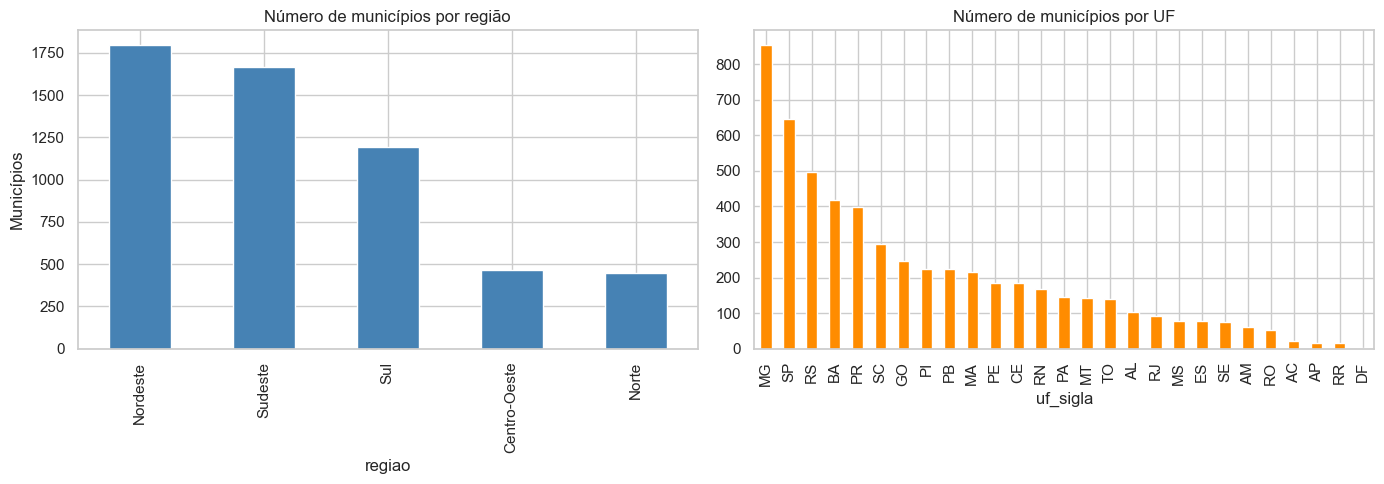

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["regiao"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Número de municípios por região")
axes[0].set_ylabel("Municípios")

df["uf_sigla"].value_counts().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Número de municípios por UF")

plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_municipios_por_regiao_uf.png", dpi=120)
plt.show()

## 6. Distribuições das variáveis numéricas

As variáveis de população e PIB tendem a ser fortemente assimétricas (poucos municípios muito grandes, como capitais, e a maioria pequena). Comparamos a escala original com a transformação `log1p`.

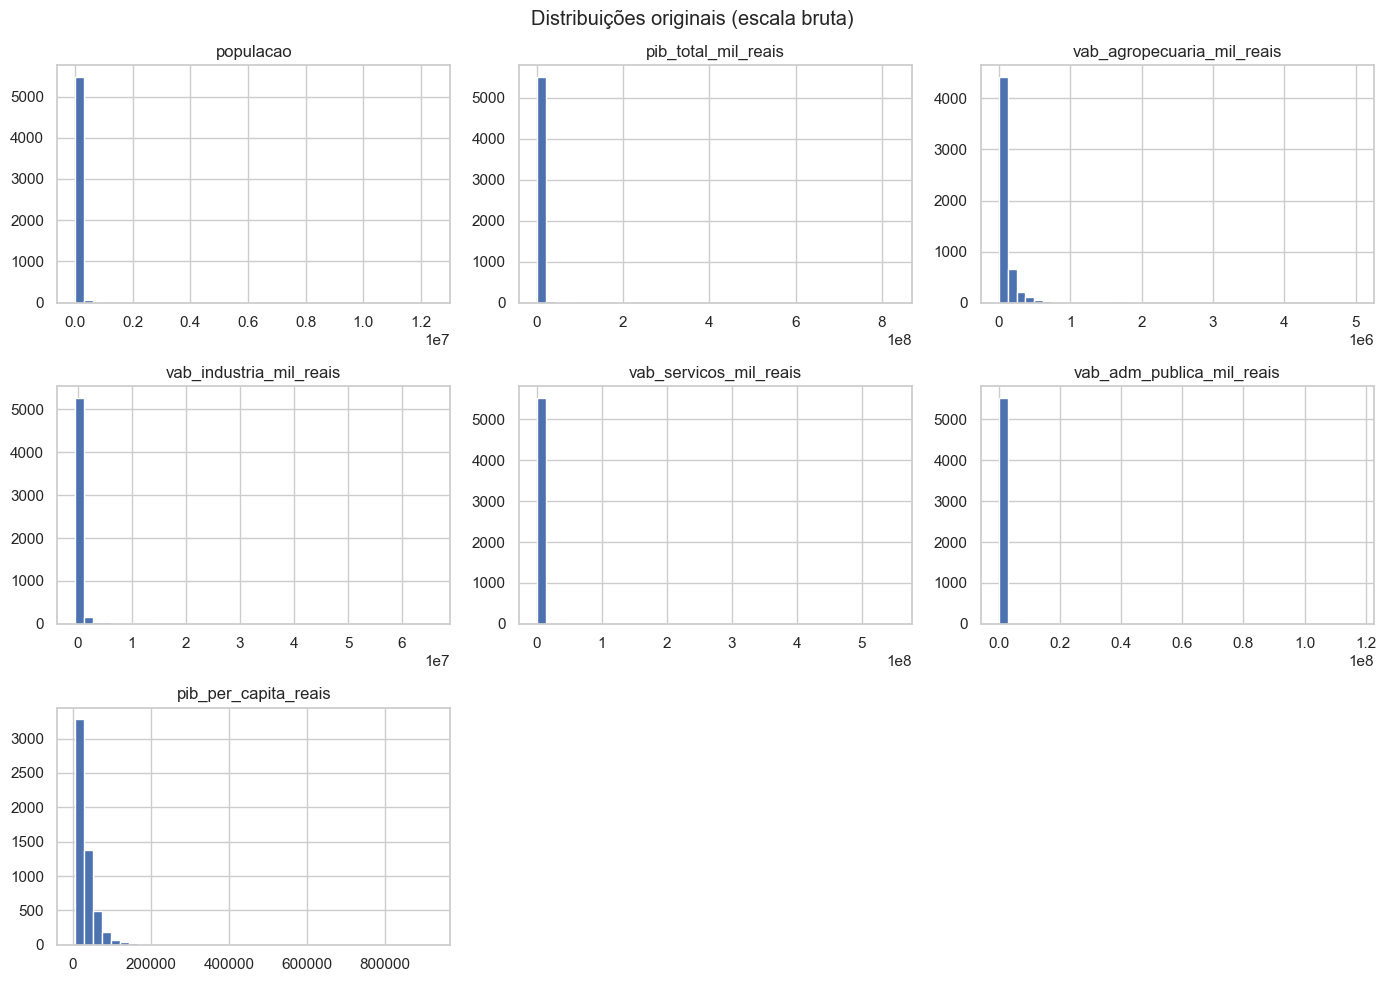

In [10]:
df[colunas_numericas].hist(figsize=(14, 10), bins=40)
plt.suptitle("Distribuições originais (escala bruta)")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_distribuicoes_originais.png", dpi=120)
plt.show()

C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


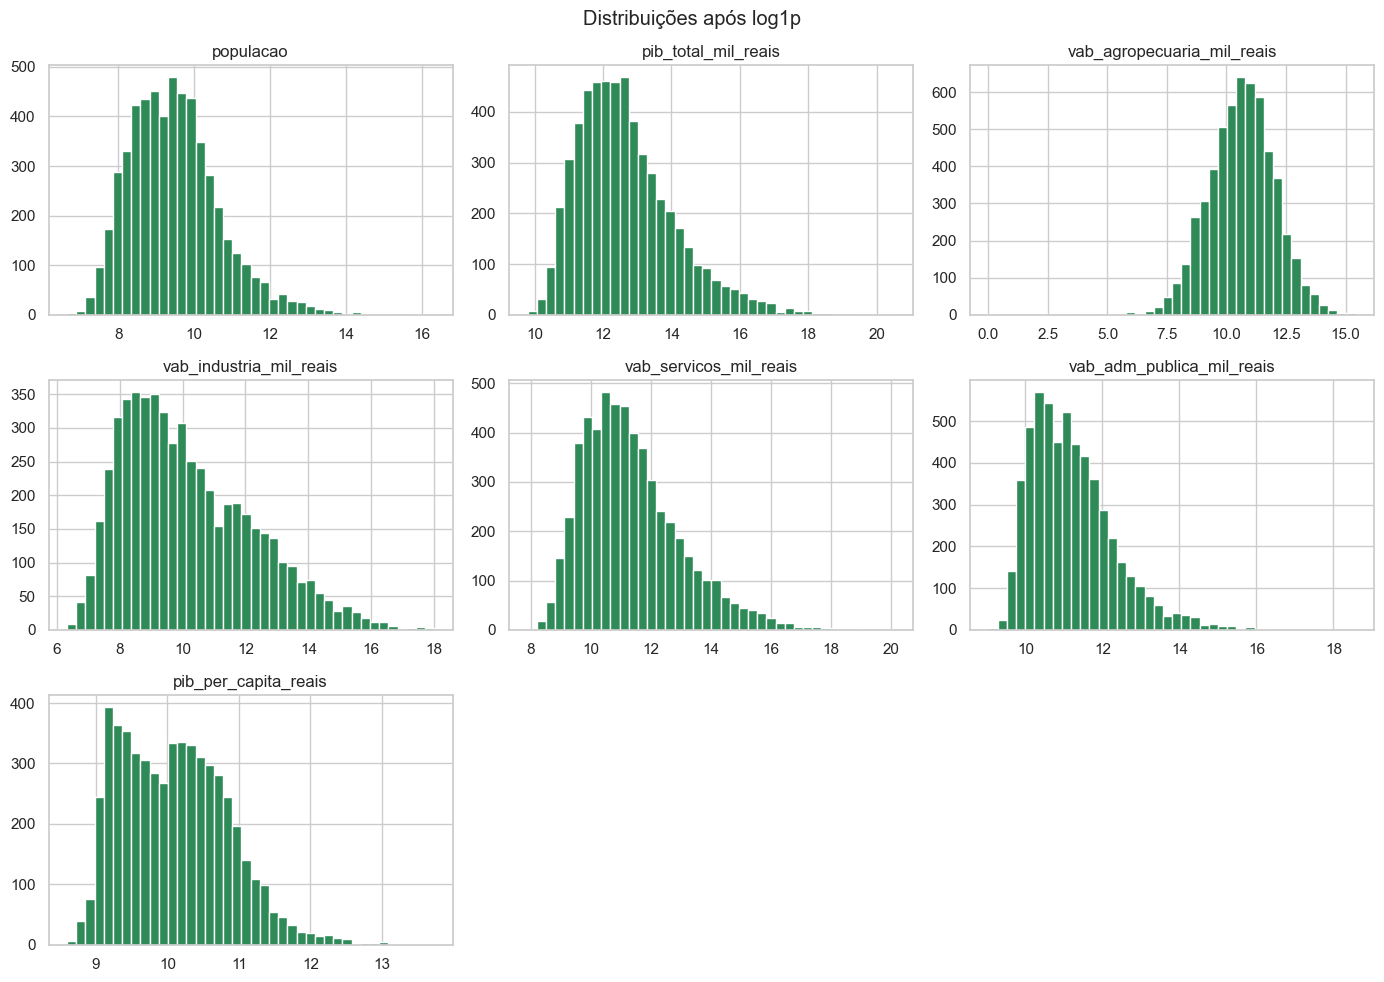

In [11]:
df_log = np.log1p(df[colunas_numericas])
df_log.hist(figsize=(14, 10), bins=40, color="seagreen")
plt.suptitle("Distribuições após log1p")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_distribuicoes_log.png", dpi=120)
plt.show()

## 7. Outliers

Poucos municípios concentram uma fração enorme da população e do PIB nacional (grandes capitais). Isso é esperado e será tratado com transformação logarítmica e/ou padronização robusta antes da modelagem.

In [12]:
# Os 10 maiores municípios em população e em PIB
print("Top 10 população:")
display_cols = ["municipio", "uf_sigla", "populacao", "pib_total_mil_reais", "pib_per_capita_reais"]
print(df.nlargest(10, "populacao")[display_cols].to_string(index=False))

print("\nTop 10 PIB total:")
print(df.nlargest(10, "pib_total_mil_reais")[display_cols].to_string(index=False))

Top 10 população:
     municipio uf_sigla  populacao  pib_total_mil_reais  pib_per_capita_reais
     São Paulo       SP 12396372.0          828980747.0          66872.851750
Rio de Janeiro       RJ  6775561.0          359632648.0          53077.914582
      Brasília       DF  3094325.0          286943782.0          92732.270204
      Salvador       BA  2900319.0           62981326.0          21715.309937
     Fortaleza       CE  2703391.0           73437739.0          27165.045308
Belo Horizonte       MG  2530701.0          105920859.0          41854.355374
        Manaus       AM  2255903.0          103281400.0          45782.730906
      Curitiba       PR  1963726.0           98000491.0          49905.379366
        Recife       PE  1661017.0           54970302.0          33094.364477
       Goiânia       GO  1555626.0           59870499.0          38486.435043

Top 10 PIB total:
     municipio uf_sigla  populacao  pib_total_mil_reais  pib_per_capita_reais
     São Paulo       SP 123

C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


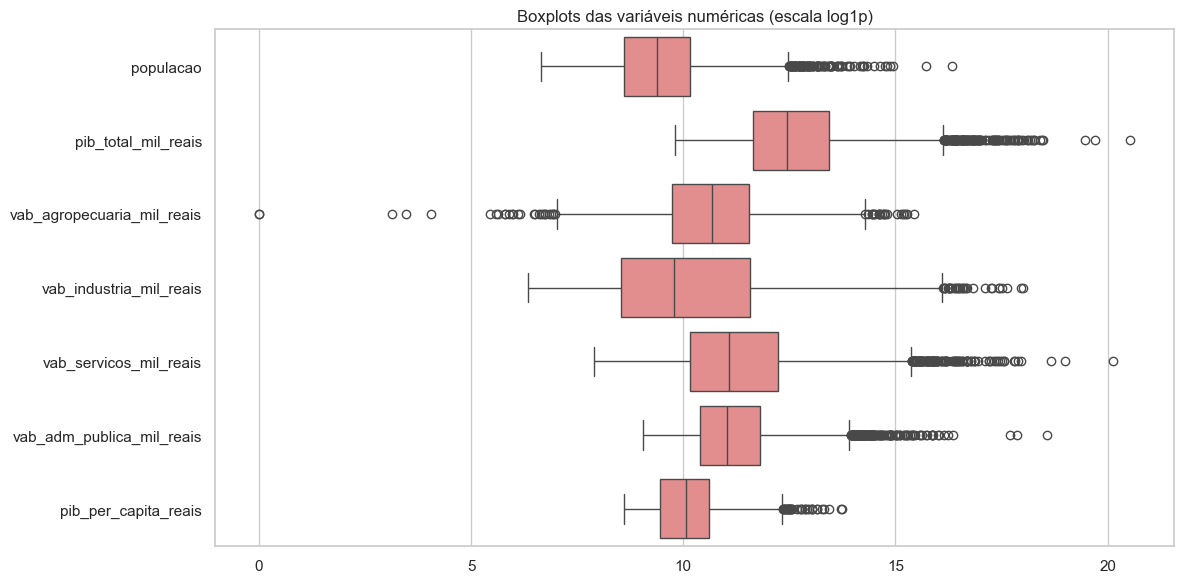

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_log, orient="h", ax=ax, color="lightcoral")
ax.set_title("Boxplots das variáveis numéricas (escala log1p)")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_boxplots_log.png", dpi=120)
plt.show()

## 8. Correlações

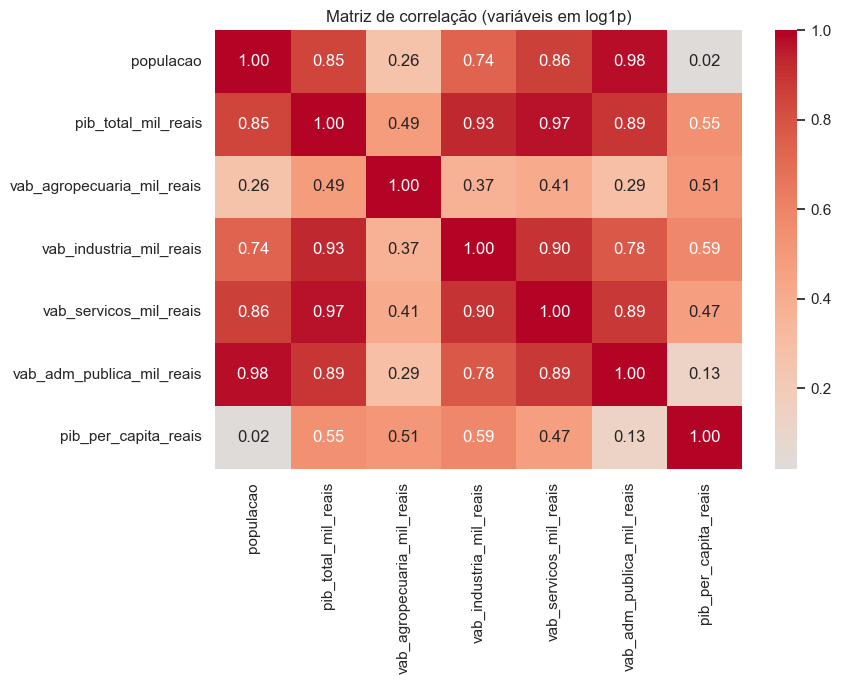

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_log.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação (variáveis em log1p)")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_correlacoes.png", dpi=120)
plt.show()

## 9. Relação entre variáveis e região

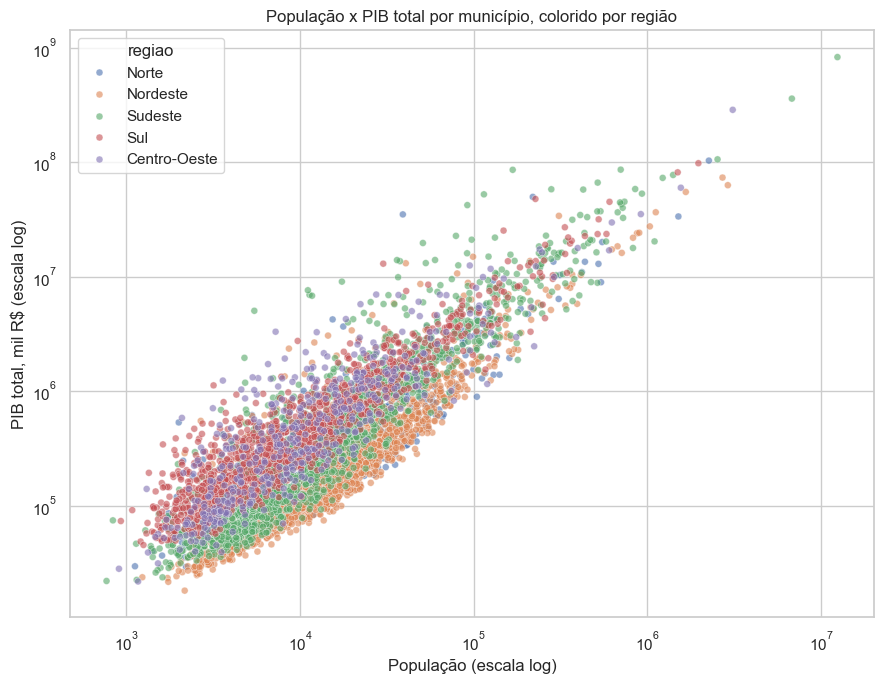

In [15]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df,
    x="populacao",
    y="pib_total_mil_reais",
    hue="regiao",
    alpha=0.6,
    s=25,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("População (escala log)")
plt.ylabel("PIB total, mil R$ (escala log)")
plt.title("População x PIB total por município, colorido por região")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_populacao_vs_pib.png", dpi=120)
plt.show()

## 10. Conclusões da EDA

- O dataset tem 5.571 municípios e apenas 1 registro com valores ausentes (município recém-criado sem série histórica de PIB no IBGE); a linha será removida antes da modelagem.
- Não há linhas duplicadas.
- Um município (Cachoeira Dourada - GO) apresenta VAB da indústria negativo — uma peculiaridade real da série do IBGE (município sede de usina hidrelétrica, com contabilização atípica de impostos/subsídios do setor elétrico). Como `log1p` não é definido para valores menores que -1, esse valor será limitado a 0 (`clip`) antes da transformação logarítmica.
- As variáveis numéricas (população, PIB, VAB setorial) são fortemente assimétricas à direita — poucas grandes capitais concentram a maior parte do PIB e da população do país. A transformação `log1p` deixa as distribuições muito mais próximas do normal, o que favorece algoritmos baseados em distância (KMeans, DBSCAN, Agglomerative).
- `pib_total_mil_reais` é fortemente correlacionado com seus componentes setoriais (agropecuária, indústria, serviços, administração pública), o que é esperado, pois um é soma dos outros — isso será considerado ao escolher as features de entrada dos modelos, para não redundar informação.
- Existem variáveis categóricas relevantes (`regiao`, `uf_sigla`, `mesorregiao`, `microrregiao`) que não podem ser usadas diretamente por KMeans/DBSCAN, mas serão aproveitadas nos experimentos com KModes e KPrototypes.

**Decisões para os próximos notebooks:**
1. Remover a linha com dados ausentes.
2. Limitar (`clip`) valores negativos de VAB a 0 antes do `log1p`.
3. Aplicar `log1p` nas variáveis numéricas antes de padronizar.
4. Separar treino/teste **antes** de qualquer ajuste de transformação (scaler, etc.), para evitar vazamento de dados.
5. Usar `regiao` como variável categórica nos experimentos de KModes/KPrototypes.